In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Telco-Customer-Churn.csv")


# Dataset shape
print("Dataset Shape:")
print(df.shape)

# Data types and non-null counts
print("\n Dataset Information:")
df.info()

# Missing values
print("\n Missing Values:")
print(df.isnull().sum())

# Summary statistics for numerical columns
print("\n Summary Statistics:")
print(df.describe())

#duplicates
df=df.drop_duplicates()

Dataset Shape:
(7043, 21)

 Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  Pape

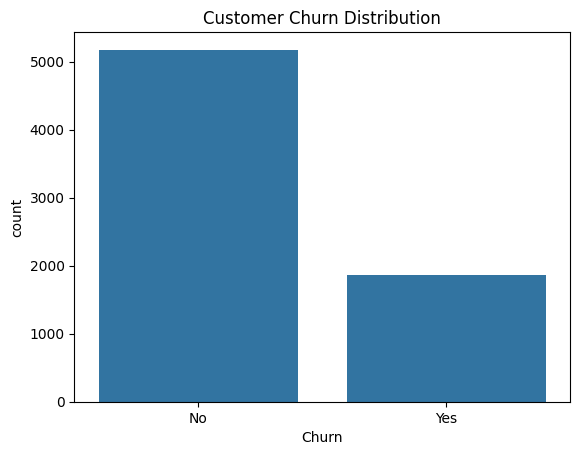

In [8]:
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

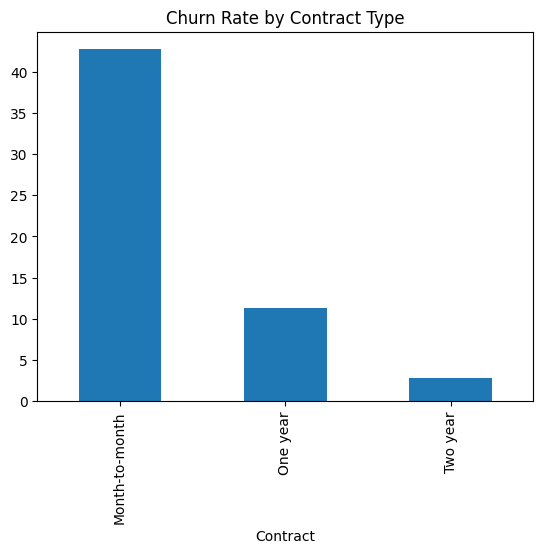

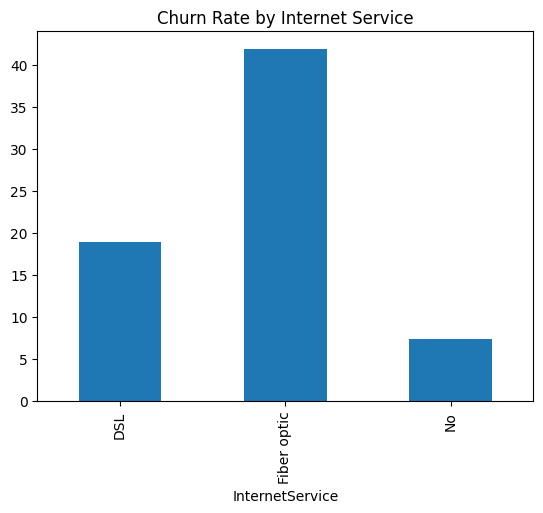

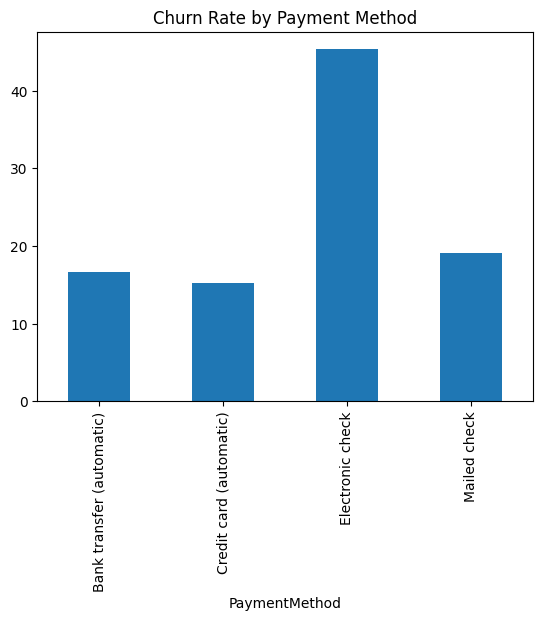

In [9]:
# Plot churn rate by: Contract Type, Internet Service, Payment Method

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

# 1. Churn Rate by Contract Type

contract_churn['Yes'].plot(kind='bar')
plt.title('Churn Rate by Contract Type')
plt.show()


# 2. Churn Rate by Internet Service

internet_churn['Yes'].plot(kind='bar')
plt.title('Churn Rate by Internet Service')
plt.show()

# 3. Churn Rate by Payment Method

payment_churn['Yes'].plot(kind='bar')
plt.title('Churn Rate by Payment Method')
plt.show()

Average Tenure and Monthly Charges
       tenure  MonthlyCharges
Churn                        
No      37.57           61.27
Yes     17.98           74.44


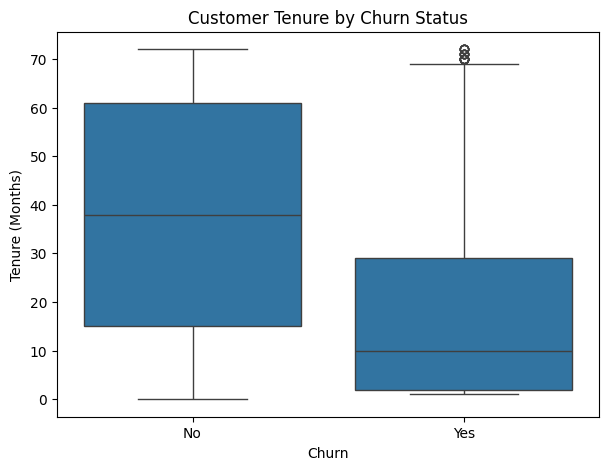

In [10]:
# Average tenure and monthly charges
avg_stats = df.groupby('Churn')[['tenure', 'MonthlyCharges']].mean().round(2)

print("Average Tenure and Monthly Charges")
print(avg_stats)

# Chart
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

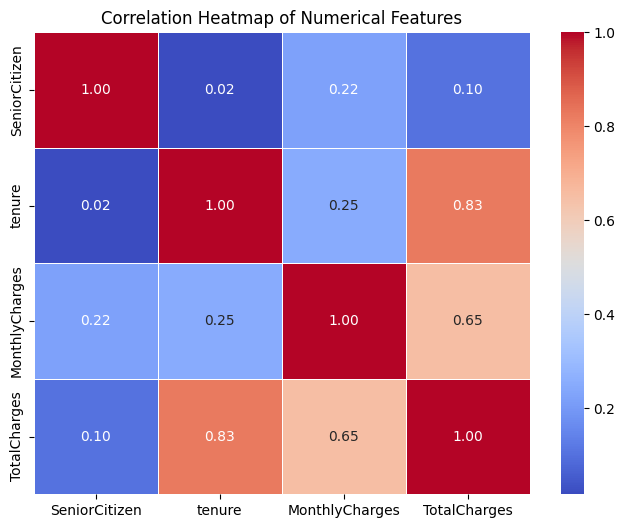

In [11]:
# Create a correlation heatmap of numerical features

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

numerical_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [12]:
print("=" * 50)
print("TOP 3 FACTORS ASSOCIATED WITH CHURN")
print("=" * 50)

# 1. Contract Type
print("\n1. CONTRACT TYPE CHURN RATE (%)")
print(
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
      .sort_values(ascending=False)
)

# 2. Average Tenure
print("\n2. AVERAGE TENURE BY CHURN STATUS")
print(
    df.groupby("Churn")["tenure"]
      .mean()
      .round(2)
)

# 3. Average Monthly Charges
print("\n3. AVERAGE MONTHLY CHARGES BY CHURN STATUS")
print(
    df.groupby("Churn")["MonthlyCharges"]
      .mean()
      .round(2)
)

print("\nINTERPRETATION")
print("- Month-to-Month customers have the highest churn rate.")
print("- Customers with lower tenure are more likely to churn.")
print("- Customers with higher monthly charges are more likely to churn.")

TOP 3 FACTORS ASSOCIATED WITH CHURN

1. CONTRACT TYPE CHURN RATE (%)
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

2. AVERAGE TENURE BY CHURN STATUS
Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64

3. AVERAGE MONTHLY CHARGES BY CHURN STATUS
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

INTERPRETATION
- Month-to-Month customers have the highest churn rate.
- Customers with lower tenure are more likely to churn.
- Customers with higher monthly charges are more likely to churn.


### Executive Summary

This analysis was conducted to understand the factors contributing to customer churn at TeleConnect India. The results indicate that customer churn is mainly influenced by contract type, tenure, and monthly charges. Customers on month-to-month contracts were found to leave the service more frequently than those on one-year or two-year contracts, suggesting that longer-term contracts help improve customer retention.

The analysis also showed that customers who churn generally have a shorter tenure with the company. This means that new customers are more likely to leave during the early stages of their subscription. In addition, customers with higher monthly charges were observed to have a greater tendency to churn, indicating that pricing may play an important role in customer satisfaction and loyalty.

Based on these findings, TeleConnect India should focus on strengthening customer retention efforts, particularly for new customers and those with high monthly bills. Encouraging customers to switch to long-term contract plans through incentives and personalized offers could help reduce churn, improve customer satisfaction, and support long-term business growth.
